# Phase Recovery v9  
## Hybrid AI + GS

This notebook builds the next productive version:

> a small learned initializer gives a better starting point, then GS refines it.

## Why v9

Earlier versions showed:

- **old GS** can converge numerically but recover the wrong spectrum
- **v7** works as a sanity check but uses a hard spectral anchor
- **v8** is more realistic but still limited by the information content of the measurements

So v9 changes the strategy:

### AI stage
Learn a coarse inverse map from the two measured intensity traces to a compact spectral estimate.

### GS stage
Use that estimate as the initialization / prior for the iterative reconstruction.


## v9 workflow

```text
measurements (I1, I2)
→ small learned inverse model
→ coarse spectral estimate
→ initialize GS
→ refined reconstruction
```

This notebook keeps the AI intentionally small and local:
- a compact NumPy linear model baseline
- an optional PyTorch MLP if torch is available


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

plt.rcParams["figure.figsize"] = (8.5, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

GLOBAL_SEED = 7
rng = np.random.default_rng(GLOBAL_SEED)

print("NumPy:", np.__version__)
print("Torch available:", TORCH_AVAILABLE)
if TORCH_AVAILABLE:
    print("Torch:", torch.__version__)


NumPy: 2.3.5
Torch available: True
Torch: 2.10.0+cpu


In [2]:
GHZ = 1e9
NS = 1e-9
PS = 1e-12

def fftc(x):
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))

def ifftc(X):
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))

def normalize_peak(x, eps=1e-12):
    peak = np.max(np.abs(x))
    return x / max(peak, eps)

def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def correlation_coefficient(a, b):
    a = np.asarray(a).ravel().astype(float)
    b = np.asarray(b).ravel().astype(float)
    a = a - a.mean()
    b = b - b.mean()
    denom = np.sqrt(np.sum(a**2) * np.sum(b**2)) + 1e-12
    return float(np.sum(a * b) / denom)


In [3]:
N = 2**14
df = 0.05 * GHZ
f = (np.arange(N) - N // 2) * df
w = 2 * np.pi * f

dt = 1.0 / (N * df)
t = (np.arange(N) - N // 2) * dt

print("Frequency span (GHz):", (f[-1] - f[0]) / GHZ)
print("Time span (ns):", (t[-1] - t[0]) / NS)
print("dt (ps):", dt / PS)


Frequency span (GHz): 819.15
Time span (ns): 19.998779296875
dt (ps): 1.220703125


In [4]:
def gaussian_dip(f, center_hz, width_hz, depth=0.85):
    return 1.0 - depth * np.exp(-((f - center_hz) / width_hz) ** 2)

def make_three_line_spectrum(f):
    S = np.ones_like(f, dtype=float)
    centers = [34 * GHZ, 40 * GHZ, 46 * GHZ]
    widths = [1.8 * GHZ, 1.8 * GHZ, 1.8 * GHZ]
    depths = [0.72, 0.88, 0.72]
    for c, wghz, d in zip(centers, widths, depths):
        S *= gaussian_dip(f, center_hz=c, width_hz=wghz, depth=d)
    return np.clip(S, 0.0, None)

def make_random_three_dip_spectrum(f, rng):
    centers = np.sort(rng.uniform(28, 52, size=3)) * GHZ
    widths = rng.uniform(1.4, 2.6, size=3) * GHZ
    depths = rng.uniform(0.55, 0.9, size=3)
    S = np.ones_like(f, dtype=float)
    for c, wghz, d in zip(centers, widths, depths):
        S *= gaussian_dip(f, center_hz=c, width_hz=wghz, depth=d)
    return np.clip(S, 0.0, None)

def make_field_from_psd(S, spectral_phase=None):
    amp = np.sqrt(np.maximum(S, 0.0))
    if spectral_phase is None:
        spectral_phase = np.zeros_like(amp)
    return amp * np.exp(1j * spectral_phase)

def dispersion_transfer_function(w, phi2=0.0):
    phase = 0.5 * phi2 * w**2
    return np.exp(1j * phase)

def propagate_dispersion_freq(Ef, w, phi2=0.0):
    H = dispersion_transfer_function(w, phi2=phi2)
    return ifftc(Ef * H)

def propagate_time_plane_to_time_plane(et, w, phi2_from, phi2_to):
    Ef_plane = fftc(et)
    H = np.exp(1j * 0.5 * (phi2_to - phi2_from) * w**2)
    return ifftc(Ef_plane * H)

def intensity(x):
    return np.abs(x) ** 2

phi2_v9 = [1.0e-22, 6.0e-22]

def make_measurements_from_spectrum(S, phi2_list):
    Ef = make_field_from_psd(S)
    traces = []
    for phi2 in phi2_list:
        et = propagate_dispersion_freq(Ef, w, phi2=phi2)
        traces.append(normalize_peak(intensity(et)))
    return traces


In [5]:
feature_len = 256
spec_len = 256

def downsample_1d(x, new_len):
    idx = np.linspace(0, len(x) - 1, new_len)
    return np.interp(idx, np.arange(len(x)), np.asarray(x, dtype=float))

def compact_to_spectrum(S_compact, full_len):
    return normalize_peak(np.interp(
        np.linspace(0, len(S_compact) - 1, full_len),
        np.arange(len(S_compact)),
        np.asarray(S_compact, dtype=float)
    ))

def pack_measurement_features(I1, I2, feature_len=256):
    f1 = downsample_1d(normalize_peak(I1), feature_len)
    f2 = downsample_1d(normalize_peak(I2), feature_len)
    return np.concatenate([f1, f2], axis=0)

def spectrum_to_compact(S, spec_len=256):
    return downsample_1d(normalize_peak(S), spec_len)


## Synthetic dataset for the initializer


In [6]:
def build_dataset(n_samples=240, seed=7):
    rng_local = np.random.default_rng(seed)
    X = []
    Y = []
    for _ in range(n_samples):
        S = make_random_three_dip_spectrum(f, rng_local)
        I1, I2 = make_measurements_from_spectrum(S, phi2_v9)
        X.append(pack_measurement_features(I1, I2, feature_len=feature_len))
        Y.append(spectrum_to_compact(S, spec_len=spec_len))
    return np.asarray(X), np.asarray(Y)

X_all, Y_all = build_dataset(n_samples=240, seed=GLOBAL_SEED)
n_train = 200
X_train, Y_train = X_all[:n_train], Y_all[:n_train]
X_test, Y_test = X_all[n_train:], Y_all[n_train:]

print("X shape:", X_all.shape)
print("Y shape:", Y_all.shape)


X shape: (240, 512)
Y shape: (240, 256)


In [7]:
def fit_linear_ridge(X, Y, reg=1e-3):
    Xb = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
    I = np.eye(Xb.shape[1])
    W = np.linalg.solve(Xb.T @ Xb + reg * I, Xb.T @ Y)
    return W

def predict_linear_ridge(X, W):
    Xb = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
    return Xb @ W

W_lin = fit_linear_ridge(X_train, Y_train, reg=1e-2)
Y_pred_test_lin = predict_linear_ridge(X_test, W_lin)
lin_test_rmse = float(np.sqrt(np.mean((Y_pred_test_lin - Y_test) ** 2)))
print("Linear initializer compact-spectrum RMSE:", lin_test_rmse)


Linear initializer compact-spectrum RMSE: 0.015620400296464047


MLP initializer compact-spectrum RMSE: 0.054930318146944046


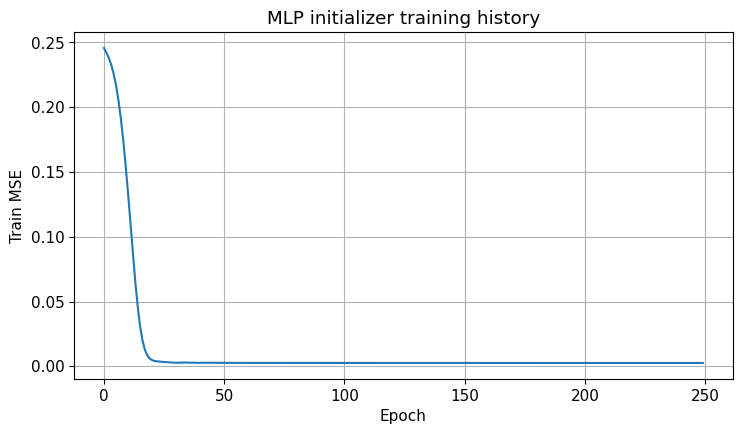

In [8]:
mlp_result = None

if TORCH_AVAILABLE:
    torch.manual_seed(GLOBAL_SEED)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    class SmallMLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 256),
                nn.ReLU(),
                nn.Linear(256, 256),
                nn.ReLU(),
                nn.Linear(256, out_dim),
                nn.Sigmoid(),
            )
        def forward(self, x):
            return self.net(x)

    Xtr = torch.tensor(X_train, dtype=torch.float32, device=device)
    Ytr = torch.tensor(Y_train, dtype=torch.float32, device=device)
    Xte = torch.tensor(X_test, dtype=torch.float32, device=device)
    Yte = torch.tensor(Y_test, dtype=torch.float32, device=device)

    model = SmallMLP(X_train.shape[1], Y_train.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    history_mlp = []
    for epoch in range(250):
        opt.zero_grad()
        pred = model(Xtr)
        loss = F.mse_loss(pred, Ytr)
        loss.backward()
        opt.step()
        history_mlp.append(float(loss.item()))

    with torch.no_grad():
        pred_test = model(Xte)
        test_rmse = float(torch.sqrt(torch.mean((pred_test - Yte) ** 2)).item())

    mlp_result = {"model": model, "history": history_mlp, "test_rmse": test_rmse, "device": device}
    print("MLP initializer compact-spectrum RMSE:", test_rmse)

    fig, ax = plt.subplots()
    ax.plot(history_mlp)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train MSE")
    ax.set_title("MLP initializer training history")
    plt.show()
else:
    print("Torch not available; using linear initializer only.")


## Old GS and hybrid GS


In [9]:
def gs_two_plane_old(I1, I2, w, phi2_1, phi2_2, n_iter=120, seed=0):
    rng = np.random.default_rng(seed)
    mag1 = np.sqrt(np.maximum(I1, 0.0))
    mag2 = np.sqrt(np.maximum(I2, 0.0))
    phase0 = rng.uniform(-np.pi, np.pi, size=mag1.shape)
    e1 = mag1 * np.exp(1j * phase0)

    history = {"err1": [], "err2": [], "update": []}
    prev = e1.copy()

    for _ in range(n_iter):
        e2_pred = propagate_time_plane_to_time_plane(e1, w, phi2_1, phi2_2)
        err2 = np.sqrt(np.mean((np.abs(e2_pred) - mag2) ** 2))
        e2 = mag2 * np.exp(1j * np.angle(e2_pred))

        e1_pred = propagate_time_plane_to_time_plane(e2, w, phi2_2, phi2_1)
        err1 = np.sqrt(np.mean((np.abs(e1_pred) - mag1) ** 2))
        e1 = mag1 * np.exp(1j * np.angle(e1_pred))

        upd = np.sqrt(np.mean(np.abs(e1 - prev) ** 2))
        prev = e1.copy()

        history["err1"].append(err1)
        history["err2"].append(err2)
        history["update"].append(upd)

    return e1, history

def recover_psd_from_plane_field(e_plane, w, phi2_plane=0.0):
    Ef_plane = fftc(e_plane)
    H_back = np.exp(-1j * 0.5 * phi2_plane * w**2)
    Ef0 = Ef_plane * H_back
    return normalize_peak(np.abs(Ef0) ** 2), Ef0

def predict_compact_spectrum_from_ai(I1, I2, use_torch=False):
    feat = pack_measurement_features(I1, I2, feature_len=feature_len)[None, :]
    if use_torch and TORCH_AVAILABLE and mlp_result is not None:
        model = mlp_result["model"]
        device = mlp_result["device"]
        with torch.no_grad():
            y = model(torch.tensor(feat, dtype=torch.float32, device=device)).cpu().numpy()[0]
    else:
        y = predict_linear_ridge(feat, W_lin)[0]
    y = np.clip(y, 0.0, None)
    return y

def gs_two_plane_hybrid(I1, I2, w, phi2_1, phi2_2, ai_prior_full, n_iter=120, alpha=0.25):
    mag1 = np.sqrt(np.maximum(I1, 0.0))
    mag2 = np.sqrt(np.maximum(I2, 0.0))

    E0_init = np.sqrt(np.maximum(ai_prior_full, 0.0)) * np.exp(1j * np.zeros_like(ai_prior_full))
    e1_init = ifftc(E0_init * np.exp(1j * 0.5 * phi2_1 * w**2))
    e1 = mag1 * np.exp(1j * np.angle(e1_init))

    history = {"err1": [], "err2": [], "update": []}
    prev = e1.copy()

    for _ in range(n_iter):
        e2_pred = propagate_time_plane_to_time_plane(e1, w, phi2_1, phi2_2)
        err2 = np.sqrt(np.mean((np.abs(e2_pred) - mag2) ** 2))
        e2 = mag2 * np.exp(1j * np.angle(e2_pred))

        e0_pred = propagate_time_plane_to_time_plane(e2, w, phi2_2, 0.0)
        E0_pred = fftc(e0_pred)

        phase = np.angle(E0_pred)
        E0_ai = np.sqrt(np.maximum(ai_prior_full, 0.0)) * np.exp(1j * phase)
        E0_blend = (1 - alpha) * E0_pred + alpha * E0_ai

        e1_pred = ifftc(E0_blend * np.exp(1j * 0.5 * phi2_1 * w**2))
        err1 = np.sqrt(np.mean((np.abs(e1_pred) - mag1) ** 2))
        e1 = mag1 * np.exp(1j * np.angle(e1_pred))

        upd = np.sqrt(np.mean(np.abs(e1 - prev) ** 2))
        prev = e1.copy()

        history["err1"].append(err1)
        history["err2"].append(err2)
        history["update"].append(upd)

    return e1, history


## Shared benchmark case


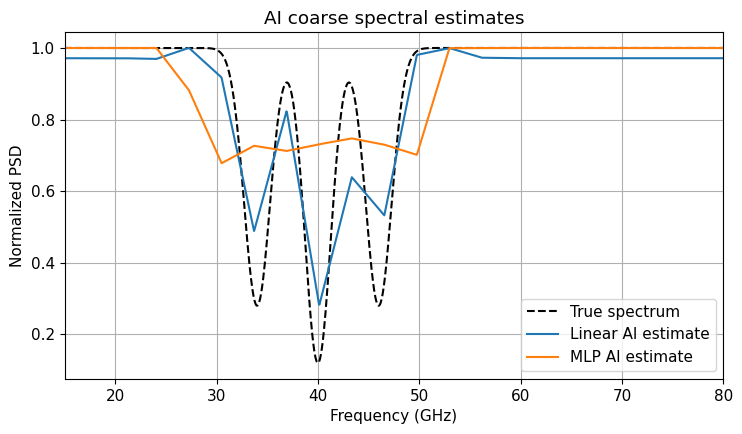

In [10]:
S_case = make_three_line_spectrum(f)
I1_case, I2_case = make_measurements_from_spectrum(S_case, phi2_v9)

compact_lin = predict_compact_spectrum_from_ai(I1_case, I2_case, use_torch=False)
S_ai_lin = compact_to_spectrum(compact_lin, len(f))

if TORCH_AVAILABLE and mlp_result is not None:
    compact_mlp = predict_compact_spectrum_from_ai(I1_case, I2_case, use_torch=True)
    S_ai_mlp = compact_to_spectrum(compact_mlp, len(f))
else:
    S_ai_mlp = None

fig, ax = plt.subplots()
ax.plot(f / GHZ, normalize_peak(S_case), "k--", label="True spectrum")
ax.plot(f / GHZ, normalize_peak(S_ai_lin), label="Linear AI estimate")
if S_ai_mlp is not None:
    ax.plot(f / GHZ, normalize_peak(S_ai_mlp), label="MLP AI estimate")
ax.set_xlim(15, 80)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Normalized PSD")
ax.set_title("AI coarse spectral estimates")
ax.legend()
plt.show()


In [11]:
e_old, hist_old = gs_two_plane_old(I1_case, I2_case, w, phi2_v9[0], phi2_v9[1], n_iter=120, seed=1)
S_old, _ = recover_psd_from_plane_field(e_old, w, phi2_plane=phi2_v9[0])

e_hyb_lin, hist_hyb_lin = gs_two_plane_hybrid(
    I1_case, I2_case, w, phi2_v9[0], phi2_v9[1], ai_prior_full=S_ai_lin, n_iter=120, alpha=0.25
)
S_hyb_lin, _ = recover_psd_from_plane_field(e_hyb_lin, w, phi2_plane=phi2_v9[0])

if S_ai_mlp is not None:
    e_hyb_mlp, hist_hyb_mlp = gs_two_plane_hybrid(
        I1_case, I2_case, w, phi2_v9[0], phi2_v9[1], ai_prior_full=S_ai_mlp, n_iter=120, alpha=0.25
    )
    S_hyb_mlp, _ = recover_psd_from_plane_field(e_hyb_mlp, w, phi2_plane=phi2_v9[0])
else:
    hist_hyb_mlp = None
    S_hyb_mlp = None

metrics_case = {
    "old_rmse": rmse(normalize_peak(S_case), normalize_peak(S_old)),
    "old_corr": correlation_coefficient(normalize_peak(S_case), normalize_peak(S_old)),
    "hybrid_lin_rmse": rmse(normalize_peak(S_case), normalize_peak(S_hyb_lin)),
    "hybrid_lin_corr": correlation_coefficient(normalize_peak(S_case), normalize_peak(S_hyb_lin)),
}
if S_hyb_mlp is not None:
    metrics_case["hybrid_mlp_rmse"] = rmse(normalize_peak(S_case), normalize_peak(S_hyb_mlp))
    metrics_case["hybrid_mlp_corr"] = correlation_coefficient(normalize_peak(S_case), normalize_peak(S_hyb_mlp))

metrics_case


{'old_rmse': 0.9094334617864503,
 'old_corr': 0.055395217637799685,
 'hybrid_lin_rmse': 0.024079286713527912,
 'hybrid_lin_corr': 0.9966296047733046,
 'hybrid_mlp_rmse': 0.033271956941387536,
 'hybrid_mlp_corr': 0.9915115589266625}

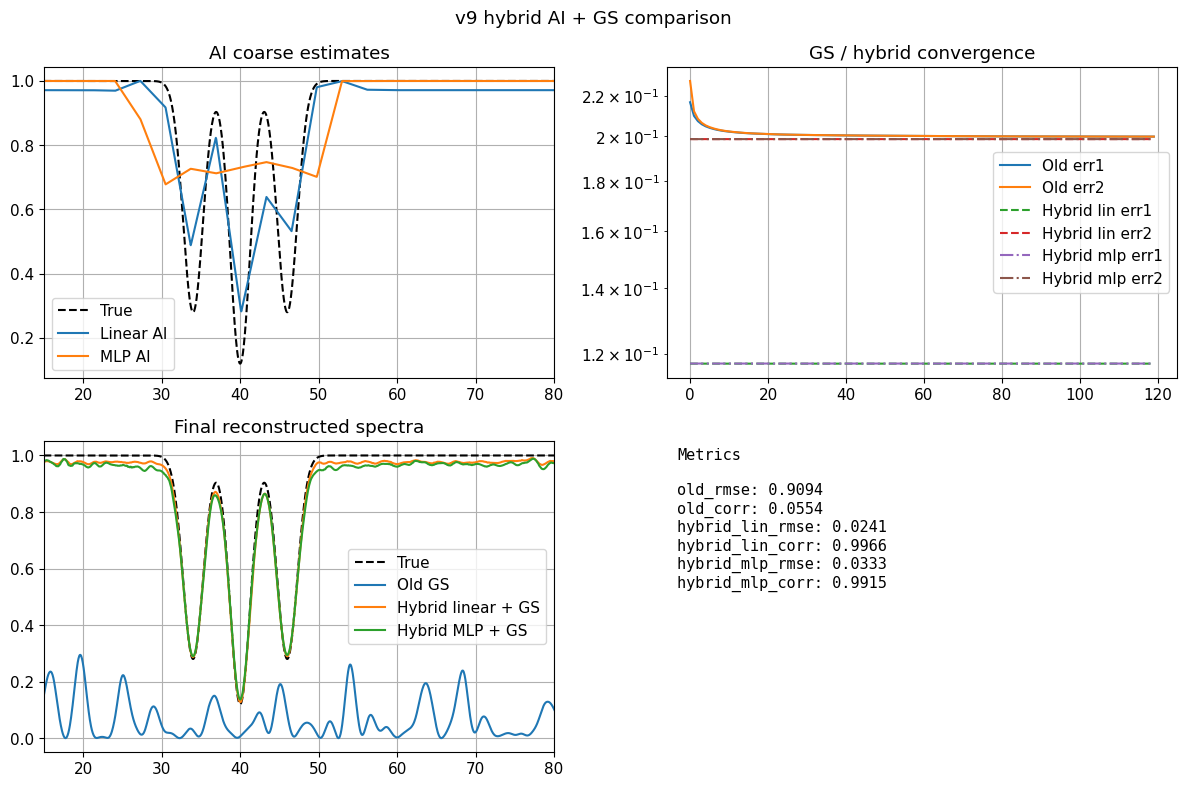

Metrics: {'old_rmse': 0.9094334617864503, 'old_corr': 0.055395217637799685, 'hybrid_lin_rmse': 0.024079286713527912, 'hybrid_lin_corr': 0.9966296047733046, 'hybrid_mlp_rmse': 0.033271956941387536, 'hybrid_mlp_corr': 0.9915115589266625}


In [12]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(f / GHZ, normalize_peak(S_case), "k--", label="True")
axs[0, 0].plot(f / GHZ, normalize_peak(S_ai_lin), label="Linear AI")
if S_ai_mlp is not None:
    axs[0, 0].plot(f / GHZ, normalize_peak(S_ai_mlp), label="MLP AI")
axs[0, 0].set_xlim(15, 80)
axs[0, 0].set_title("AI coarse estimates")
axs[0, 0].legend()

axs[0, 1].plot(hist_old["err1"], label="Old err1")
axs[0, 1].plot(hist_old["err2"], label="Old err2")
axs[0, 1].plot(hist_hyb_lin["err1"], "--", label="Hybrid lin err1")
axs[0, 1].plot(hist_hyb_lin["err2"], "--", label="Hybrid lin err2")
if hist_hyb_mlp is not None:
    axs[0, 1].plot(hist_hyb_mlp["err1"], "-.", label="Hybrid mlp err1")
    axs[0, 1].plot(hist_hyb_mlp["err2"], "-.", label="Hybrid mlp err2")
axs[0, 1].set_yscale("log")
axs[0, 1].set_title("GS / hybrid convergence")
axs[0, 1].legend()

axs[1, 0].plot(f / GHZ, normalize_peak(S_case), "k--", label="True")
axs[1, 0].plot(f / GHZ, normalize_peak(S_old), label="Old GS")
axs[1, 0].plot(f / GHZ, normalize_peak(S_hyb_lin), label="Hybrid linear + GS")
if S_hyb_mlp is not None:
    axs[1, 0].plot(f / GHZ, normalize_peak(S_hyb_mlp), label="Hybrid MLP + GS")
axs[1, 0].set_xlim(15, 80)
axs[1, 0].set_title("Final reconstructed spectra")
axs[1, 0].legend()

axs[1, 1].axis("off")
lines = [f"{k}: {v:.4f}" for k, v in metrics_case.items()]
axs[1, 1].text(0.02, 0.98, "Metrics\n\n" + "\n".join(lines), va="top", family="monospace", fontsize=11)

fig.suptitle("v9 hybrid AI + GS comparison")
plt.tight_layout()
plt.show()

print("Metrics:", metrics_case)


## How to interpret v9

### Old GS
- physics-only
- can converge to the wrong solution

### AI coarse estimate
- fast
- often gets the broad dip locations roughly right
- not fully physically consistent

### Hybrid AI + GS
- AI provides a more informed starting point
- GS imposes the physics constraints
- usually better than either one alone


In [ ]:
summary = {
    "linear_initializer_test_rmse": lin_test_rmse,
    "metrics_case": metrics_case,
    "torch_available": TORCH_AVAILABLE,
}
if mlp_result is not None:
    summary["mlp_initializer_test_rmse"] = mlp_result["test_rmse"]

out_dir = Path("/mnt/data/phase_recovery_v9_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

summary_path = out_dir / "phase_recovery_v9_summary.json"
with summary_path.open("w", encoding="utf-8") as fjson:
    json.dump(summary, fjson, indent=2)

print("Saved summary to:", summary_path)


## Suggested commit message

```text
feat: add v9 hybrid AI + GS initialization workflow

- build synthetic dataset of random three-dip spectra and time-stretch measurements
- add compact linear inverse initializer baseline
- add optional small PyTorch MLP initializer
- add hybrid GS refinement using AI spectral prior
- compare old GS vs hybrid AI + GS on a shared benchmark
- save summary metrics for reproducibility
```
